In [1]:
import scipy.io as sio
import pandas as pd

# 1. Load the .mat file into a Python dictionary
mat_data = sio.loadmat('PMUData.mat',
                       squeeze_me = True,
                       struct_as_record=False)

# 2. View available variable names/keys hidden inside the file
print("Variables in file:", mat_data.keys())




Variables in file: dict_keys(['__header__', '__version__', '__globals__', 'AttackLocation', 'PMU', 'PMU_SamplingFreq', 'PMU_samples', 'SimulationTime', 'TimeStep_of_simulation', 'fmeas_con', 'pelect', 't'])


In [2]:
matrix_data = mat_data['PMU']
print(type(matrix_data))
print(matrix_data._fieldnames)

<class 'scipy.io.matlab._mio5_params.mat_struct'>
['Vm', 'Va', 'f', 'fdot', 'Im', 'Ia', 'Id', 'TimeStamps']


In [11]:
bus = 19

df = pd.DataFrame({
    "Voltage": matrix_data.Vm[:, bus][:1499],
    "Frequency": matrix_data.f[:,bus][:1499] / 60,
    "RoCoF": matrix_data.fdot[:,bus],
})

df.index = matrix_data.TimeStamps[:1499]
df

,Voltage,Frequency,RoCoF
0.02,0.990432,1.0,0.000000
0.04,0.990432,1.0,0.000000
0.06,0.990432,1.0,0.000000
0.08,0.990432,1.0,0.000000
0.10,0.990432,1.0,0.000000
...,...,...,...
29.90,0.989601,1.0,-0.000301
29.92,0.989604,1.0,-0.000293
29.94,0.989607,1.0,-0.000283
29.96,0.989609,1.0,-0.000270


In [12]:
import numpy as np
# Create new time index with 0.001 s spacing
new_index = np.arange(df.index[0], df.index[-1] + 0.001, 0.001)

# Interpolate all columns onto the new time grid
df = df.reindex(df.index.union(new_index)).interpolate(method="index")
df = df.loc[new_index]

df.index -= 0.02
df

,Voltage,Frequency,RoCoF
0.000,0.990432,1.0,0.000000
0.001,0.990432,1.0,0.000000
0.002,0.990432,1.0,0.000000
0.003,0.990432,1.0,0.000000
0.004,0.990432,1.0,0.000000
...,...,...,...
29.956,0.989611,1.0,-0.000259
29.957,0.989612,1.0,-0.000258
29.958,0.989612,1.0,-0.000257
29.959,0.989612,1.0,-0.000257


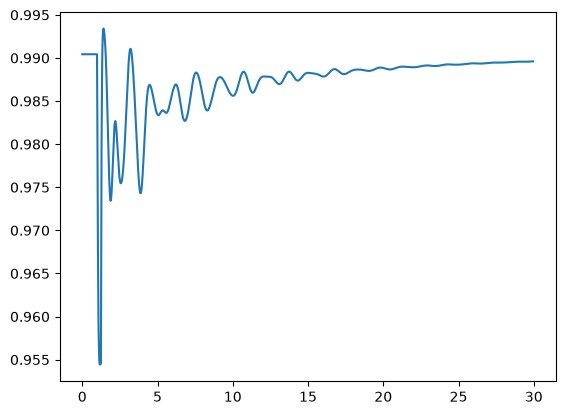

In [13]:
import matplotlib.pyplot as plt
voltage_pu = df.loc[:,"Voltage"]
plt.plot(voltage_pu.index, voltage_pu)

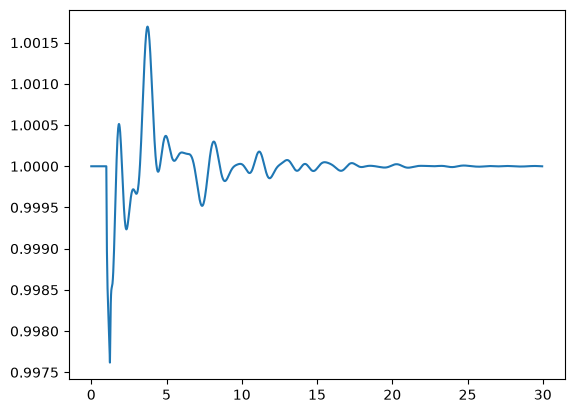

In [14]:
freq = df.loc[:,"Frequency"]
plt.plot(freq.index, freq)

In [15]:
df.to_excel('disturbance_profile.xlsx', index=True)